# Notebook 6.4: Does Filtering Improve Trading Signals?

## Financial Trading with Python, 2nd Edition

---

This is the payoff notebook. In Notebooks 6.1 through 6.3, we built statistical foundations, applied classical filters, and explored advanced signal processing techniques. All of that work leads to one question: does any of it actually improve our VIXY tail hedge strategy?

The test is straightforward. Our strategy compares SPY's 10-day realized volatility against a VIX reference level. Currently, that reference is the 90-day SMA of VIX. We replace the SMA with each of our alternative filters, keep everything else identical, and compare the results. Same strategy logic, same data, same time period — only the VIX signal input changes.

If a filter produces better risk-adjusted returns, it has earned its complexity. If it does not, the simple SMA wins by default because it is easier to implement, easier to understand, and has no boundary effects.

This notebook covers:

- Experimental setup and signal generation for each filter variant
- Where the signals agree and disagree
- Performance comparison across key metrics
- Statistical significance testing
- The verdict

## Section 1: Setup and Data Loading

In [1]:
# --- Install required packages with pinned versions ---
# These are not included in the standard Colab environment.
# We pin versions to ensure reproducibility as Colab updates.

!pip install filterpy==1.4.5 PyWavelets==1.6.0 --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 24.1 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from filterpy.kalman import KalmanFilter
import pywt
import warnings

warnings.filterwarnings('ignore')
sns.set_theme()

pd.set_option('display.max_columns', 15)
pd.set_option('display.width', 120)
pd.set_option('display.float_format', '{:.4f}'.format)

### 1.1 Loading Data and Defining Helper Functions

We load the case study data and recreate all the filter functions from Notebook 6.3. We also need the strategy weight calculation function from vixy_tail_hedge.py so we can run the strategy with each filtered signal.

In [3]:
# --- Load case study data ---
df_prices = pd.read_parquet('case_study_prices.parquet')
df_returns = df_prices.pct_change().dropna()
vix = df_prices['^VIX'].copy()

print(f"Data loaded: {df_prices.shape[0]} trading days")
print(f"Date range: {df_prices.index[0].strftime('%Y-%m-%d')} to "
      f"{df_prices.index[-1].strftime('%Y-%m-%d')}")

Data loaded: 3771 trading days
Date range: 2011-01-04 to 2025-12-31


### 1.2 Strategy Weight Calculation

Throughout this book, we have referenced the VIXY tail hedge strategy conceptually: when realized volatility exceeds a VIX reference level, we allocate a portion of the portfolio to VIXY as a tail hedge. Here we assemble that logic in code for the first time so we can test whether different VIX filters produce different strategy outcomes.

The strategy will be formalized, backtested with a proper event-driven engine, and rigorously evaluated in Chapters 7-8. For now, we implement a simplified version that calculates daily portfolio weights based on the signal. The key feature of this implementation is that the VIX reference level is a parameter we can swap out: 90-day SMA, EMA, Kalman-smoothed VIX, wavelet-denoised VIX, or any other filtered version. Everything else stays identical, isolating the effect of the filter.

In [4]:
# --- Recreate filter functions from Notebook 6.3 ---
# These are identical to the functions we built and tested previously.
# We collect them here so this notebook is self-contained.

def apply_kalman_filter(series, process_noise=0.01, measurement_noise=1.0):
    """
    Apply a univariate Kalman filter to estimate the hidden state of a time series.
    See Notebook 6.3 Section 2 for detailed explanation.
    """
    kf = KalmanFilter(dim_x=1, dim_z=1)
    kf.F = np.array([[1.0]])
    kf.H = np.array([[1.0]])
    kf.Q = np.array([[process_noise]])
    kf.R = np.array([[measurement_noise]])
    kf.x = np.array([[series.iloc[0]]])
    kf.P = np.array([[1.0]])

    filtered_values = []
    for value in series.values:
        kf.predict()
        kf.update(np.array([[value]]))
        filtered_values.append(kf.x[0, 0])

    return pd.Series(filtered_values, index=series.index, name='Kalman')


def fourier_lowpass(series, min_period):
    """
    Apply a low-pass Fourier filter that removes frequency components
    with periods shorter than min_period.
    See Notebook 6.3 Section 3 for detailed explanation.
    """
    values = series.values.copy()
    n = len(values)
    fft_values = np.fft.fft(values)
    freqs = np.fft.fftfreq(n, d=1.0)
    cutoff_freq = 1.0 / min_period
    mask = np.abs(freqs) > cutoff_freq
    fft_filtered = fft_values.copy()
    fft_filtered[mask] = 0
    filtered = np.fft.ifft(fft_filtered).real
    return pd.Series(filtered, index=series.index)


def wavelet_denoise(series, wavelet='db4', level=4, threshold_multiplier=1.0):
    """
    Denoise a time series using wavelet soft thresholding.
    See Notebook 6.3 Section 4 for detailed explanation.
    """
    values = series.values if hasattr(series, 'values') else series
    coeffs = pywt.wavedec(values, wavelet, level=level)
    sigma = np.median(np.abs(coeffs[-1])) / 0.6745
    n = len(values)
    threshold = sigma * np.sqrt(2 * np.log(n)) * threshold_multiplier
    denoised_coeffs = [coeffs[0]]
    for detail in coeffs[1:]:
        denoised_coeffs.append(pywt.threshold(detail, threshold, mode='soft'))
    denoised = pywt.waverec(denoised_coeffs, wavelet)
    denoised = denoised[:len(values)]
    if hasattr(series, 'index'):
        return pd.Series(denoised, index=series.index)
    return denoised


def calculate_vixy_weights(df_prices, vix_reference, std_period=10,
                           risky_portion=0.8):
    """
    Calculate daily weights for the VIXY tail hedge strategy.

    This is the first time we are assembling the strategy signal logic
    in code. The concept has been referenced throughout Chapters 3-6,
    and we will formalize, backtest, and evaluate it in Chapters 7-8.
    Here we need it to test whether different VIX filters produce
    different strategy outcomes.

    The signal logic:
      - Calculate SPY 10-day realized volatility (annualized, in %)
      - Compare it to a VIX reference level (the filter we are testing)
      - If realized vol > VIX reference: allocate to VIXY (tail hedge ON)
      - If realized vol <= VIX reference: allocate to BIL (tail hedge OFF)
      - SPY allocation is always constant at risky_portion (80%)
      - VIXY allocation when active is VIX/100, capped at 20%
      - BIL receives the remainder of the non-SPY allocation

    Parameters:
    -----------
    df_prices : DataFrame
        Daily prices with columns SPY, BIL, VIXY, ^VIX
    vix_reference : pd.Series
        The VIX reference level to compare against realized vol.
        This is what we swap out to test different filters:
        SMA, EMA, Kalman-smoothed VIX, etc.
    std_period : int
        Period for SPY realized volatility (default 10 trading days)
    risky_portion : float
        Constant allocation to SPY (default 0.8, i.e. 80%)

    Returns:
    --------
    DataFrame with columns [SPY, BIL, VIXY] containing daily weights
    """
    df = df_prices.copy()

    # Calculate SPY 10-day annualized realized volatility (in %)
    # This is the "trigger" side of the signal
    df['spy_returns'] = df['SPY'].pct_change()
    df['spy_realized_vol_pct'] = (df['spy_returns']
                                   .rolling(window=std_period)
                                   .std() * np.sqrt(252) * 100)

    # Align the VIX reference series (the "threshold" side of the signal)
    df['vix_ref'] = vix_reference

    # Signal: when realized vol exceeds the VIX reference,
    # something unusual is happening and we want tail protection
    df['signal'] = df['spy_realized_vol_pct'] > df['vix_ref']

    # VIXY allocation when signal is active: VIX level / 100, capped at 20%
    # Higher VIX = larger hedge position, up to the 20% maximum
    df['vixy_alloc'] = np.where(df['signal'],
                                np.minimum(df['^VIX'] / 100, 0.2),
                                0.0)

    # BIL gets the remainder of the non-SPY allocation (safe portion)
    df['bil_alloc'] = (1.0 - risky_portion) - df['vixy_alloc']

    # SPY allocation is always constant
    df['spy_alloc'] = risky_portion

    # Build weights DataFrame
    df_weights = df[['spy_alloc', 'bil_alloc', 'vixy_alloc']].copy()
    df_weights.columns = ['SPY', 'BIL', 'VIXY']
    df_weights = df_weights.dropna()

    return df_weights

print("Helper functions loaded:")
print("  - apply_kalman_filter()")
print("  - fourier_lowpass()")
print("  - wavelet_denoise()")
print("  - calculate_vixy_weights()")


Helper functions loaded:
  - apply_kalman_filter()
  - fourier_lowpass()
  - wavelet_denoise()
  - calculate_vixy_weights()


## Section 2: Generating Signals from Each Filter

We now apply each filter to VIX and generate strategy weights using each filtered version as the reference level. We test six variants:

1. **90-day SMA** (our baseline — this is what the strategy currently uses)
2. **90-day EMA** (less lag than SMA, tested in Notebook 6.2)
3. **Kalman filter** (adaptive smoothing, no boundary effects)
4. **Fourier low-pass** (keep periods > 90 days)
5. **Wavelet denoised** (standard threshold)
6. **Wavelet trend only** (cA4 approximation component — the pure trend from the decomposition)

The last variant is new. Instead of denoising (which keeps a smoothed version of the full signal), we extract only the trend component (cA4) from the wavelet decomposition. This is the slowest-moving component and represents the underlying volatility regime stripped of all faster fluctuations.

In [5]:
# --- Generate filtered VIX reference series for each variant ---

# 1. Baseline: 90-day SMA (what the strategy currently uses)
vix_sma_90 = vix.rolling(window=90).mean()

# 2. Alternative MA: 90-day EMA (faster response, less lag)
vix_ema_90 = vix.ewm(span=90).mean()

# 3. Kalman filter (Q=0.01, R=1.0 — baseline from Notebook 6.3)
vix_kalman = apply_kalman_filter(vix, process_noise=0.01, measurement_noise=1.0)

# 4. Fourier low-pass (keep periods > 90 days)
vix_fourier = fourier_lowpass(vix, min_period=90)

# 5. Wavelet denoised (standard threshold)
vix_wavelet = wavelet_denoise(vix, threshold_multiplier=1.0)

# 6. Wavelet trend only (cA4 approximation component)
#    This extracts just the slow-moving trend, discarding ALL detail levels
coeffs = pywt.wavedec(vix.values, 'db4', level=4)
trend_coeffs = [coeffs[0]] + [np.zeros_like(c) for c in coeffs[1:]]
vix_wavelet_trend = pd.Series(
    pywt.waverec(trend_coeffs, 'db4')[:len(vix)],
    index=vix.index
)

# --- Generate weights for each variant ---
variants = {
    '90-day SMA (baseline)': vix_sma_90,
    '90-day EMA': vix_ema_90,
    'Kalman': vix_kalman,
    'Fourier (>90d)': vix_fourier,
    'Wavelet denoise': vix_wavelet,
    'Wavelet trend': vix_wavelet_trend,
}

weights_by_variant = {}
for name, vix_ref in variants.items():
    weights_by_variant[name] = calculate_vixy_weights(df_prices, vix_ref)

# --- Report signal summary ---
print("Signal Variants Generated")
print("=" * 65)
print(f"{'Variant':<25} {'Days with Data':>15} {'Hedge Active %':>15}")
print("-" * 65)
for name, weights in weights_by_variant.items():
    hedge_pct = (weights['VIXY'] > 0).mean() * 100
    print(f"{name:<25} {len(weights):>15} {hedge_pct:>14.1f}%")

Signal Variants Generated
Variant                    Days with Data  Hedge Active %
-----------------------------------------------------------------
90-day SMA (baseline)                3771           19.9%
90-day EMA                           3771           18.9%
Kalman                               3771           14.3%
Fourier (>90d)                       3771           16.7%
Wavelet denoise                      3771           14.6%
Wavelet trend                        3771           14.6%


The "Hedge Active %" column is already revealing. The six variants agree on the overall structure (the hedge is active a minority of the time, as intended) but disagree on how often to trigger it.

The 90-day SMA triggers the hedge most frequently at 19.9% of trading days. This makes sense: the SMA is the slowest to respond, so once realized volatility exceeds the SMA, the SMA takes a long time to catch up, keeping the signal active longer. The EMA at 18.9% is slightly less because it responds faster — when VIX rises, the EMA reference rises with it, turning off the signal sooner.

The Kalman, wavelet denoise, and wavelet trend all cluster around 14.3-14.6%, meaning they trigger the hedge about 25% less often than the SMA. These filters track VIX more closely, so the gap between realized volatility and the VIX reference is smaller and the signal triggers less frequently. Less frequent triggering could mean fewer false signals (good) or missed protection during genuine crises (bad). The performance comparison will tell us which.

Fourier sits in between at 16.7%, but remember from Notebook 6.3 that its values are contaminated by lookahead bias. Its "Hedge Active %" in live trading would likely be different from what we see here.

Now let us look at exactly when the signals disagree.

### 2.1 Where Do the Signals Disagree?

The aggregate statistics tell us how often each filter triggers the hedge, but what matters for performance is when they disagree. A filter that triggers the hedge two days earlier during a crisis could capture a large VIXY spike. A filter that triggers false signals during calm markets will bleed money on VIXY's persistent decay. We compare the daily signal (hedge on/off) across all variants to see where they diverge.

In [6]:
# --- Build a signal comparison DataFrame ---
# For each variant, extract the daily hedge signal (1 = hedge on, 0 = hedge off)
# Then count how many variants agree on each day

df_signals = pd.DataFrame(index=weights_by_variant['90-day SMA (baseline)'].index)

for name, weights in weights_by_variant.items():
    # Align to the common index (some variants may have slightly different lengths)
    signal = (weights['VIXY'] > 0).astype(int)
    df_signals[name] = signal.reindex(df_signals.index)

# Count agreement: how many of the 6 variants say "hedge on" each day
df_signals['agreement_count'] = df_signals.sum(axis=1)

# Classify each day
# All agree off (0): unanimous calm
# All agree on (6): unanimous hedge
# Mixed (1-5): disagreement — these are the interesting days
unanimous_off = (df_signals['agreement_count'] == 0).sum()
unanimous_on = (df_signals['agreement_count'] == 6).sum()
disagreement = len(df_signals) - unanimous_off - unanimous_on

print("Signal Agreement Across Filter Variants")
print("=" * 55)
print(f"Total trading days:           {len(df_signals):>6}")
print(f"All 6 agree: hedge OFF        {unanimous_off:>6} ({unanimous_off/len(df_signals)*100:.1f}%)")
print(f"All 6 agree: hedge ON         {unanimous_on:>6} ({unanimous_on/len(df_signals)*100:.1f}%)")
print(f"Disagreement (mixed signals)  {disagreement:>6} ({disagreement/len(df_signals)*100:.1f}%)")

Signal Agreement Across Filter Variants
Total trading days:             3771
All 6 agree: hedge OFF          2845 (75.4%)
All 6 agree: hedge ON            360 (9.5%)
Disagreement (mixed signals)     566 (15.0%)


The filters agree on 85% of trading days: 75.4% unanimous hedge off (calm markets, no protection needed) and 9.5% unanimous hedge on (clearly elevated volatility, everyone agrees we need protection). These are the easy days where your choice of filter does not matter.

The 15% disagreement days (566 trading days) are where the filter choice actually affects performance. These are the borderline days: realized volatility is close to the VIX reference, and small differences in how each filter smooths VIX tip the signal one way or the other. Whether those borderline calls turn out to be profitable hedges or costly false signals is what drives the performance differences between variants.

A 15% disagreement rate is meaningful. Over 15 years of daily trading, that is roughly 566 days where your strategy behaves differently depending on which filter you chose. If those days cluster around crisis periods (where VIXY makes large moves), the performance impact could be substantial.

## Section 3: Performance Comparison

Now we calculate portfolio returns for each variant and compare them on the metrics that matter: total return, risk-adjusted return (Sharpe ratio), maximum drawdown, and volatility. We use a simplified return calculation: the daily portfolio return is the weighted average of each asset's daily return, using the weights from the previous day (no lookahead bias in the portfolio construction).

### 3.1 A Note on This Backtest

The backtest we run below is a simplified weight-based return calculation, not a full event-driven backtest. It does not account for transaction costs, slippage, rebalancing frequency constraints, or the mechanics of actually executing trades. We use it here because our goal is to isolate the effect of the VIX filter on the strategy signal, not to produce a realistic P&L estimate. In Chapter 8, we will build a proper backtesting framework that handles all of these real-world frictions.

**Important: how to interpret the results.** The VIXY tail hedge strategy is not designed to beat a buy-and-hold SPY portfolio on total return. That is not its objective. The strategy permanently allocates 80% to SPY and 20% to a defensive sleeve (BIL or VIXY). The 20% defensive allocation will always drag total returns relative to 100% SPY during bull markets, because BIL earns near-zero returns and VIXY has a negative expected return from contango decay.

The strategy's value lies in risk-adjusted performance: delivering more stable returns with lower volatility and shallower drawdowns. When markets crash, the VIXY hedge should offset some of the SPY losses, reducing the overall portfolio drawdown. Over time, this downside protection should produce a better Sharpe ratio (return per unit of risk) even if total return is lower. This is the same logic behind any hedged portfolio: you give up some upside to avoid the worst of the downside.

When reading the equity curves below, focus on the smoothness of the lines (less volatility), the behavior during the 2020 COVID crash and 2022 drawdown (downside protection), and the relative ranking of the filter variants against each other. The comparison that matters is not strategy vs. SPY buy-and-hold — it is which filter produces the best risk-adjusted strategy performance. The SPY buy-and-hold line is included only as a reference point.

The results should be interpreted as relative comparisons between filter variants (does filter A produce a better signal than filter B?), not as estimates of actual strategy performance. The rank ordering is what matters, not the absolute return numbers.

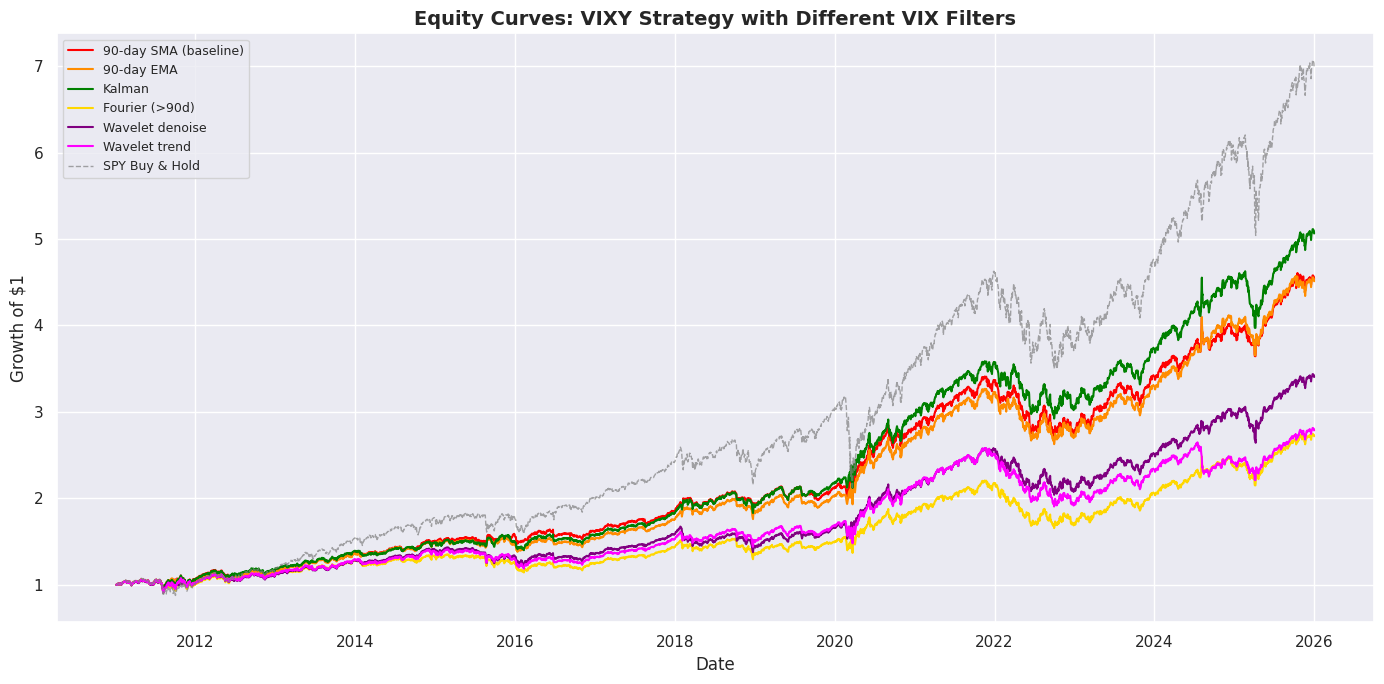

In [7]:
# --- Calculate portfolio returns for each variant ---
# Daily portfolio return = sum of (weight_i * return_i) for each asset
# We use previous day's weights to avoid lookahead bias:
#   today's return is calculated using yesterday's weights applied to today's asset returns

# Asset returns for SPY, BIL, VIXY
asset_returns = df_returns[['SPY', 'BIL', 'VIXY']].copy()

portfolio_returns = {}
for name, weights in weights_by_variant.items():
    # Align weights and returns to common dates
    common_idx = weights.index.intersection(asset_returns.index)
    w = weights.loc[common_idx]
    r = asset_returns.loc[common_idx]

    # Shift weights by 1 day: use yesterday's weights with today's returns
    # This ensures no lookahead bias in portfolio construction
    w_lagged = w.shift(1).dropna()
    r_aligned = r.loc[w_lagged.index]

    # Daily portfolio return = weighted sum of asset returns
    port_ret = (w_lagged * r_aligned).sum(axis=1)
    portfolio_returns[name] = port_ret

# Also calculate a buy-and-hold SPY benchmark for context
spy_benchmark = asset_returns['SPY'].loc[portfolio_returns['90-day SMA (baseline)'].index]

# --- Calculate cumulative returns (growth of $1) ---
cumulative = pd.DataFrame()
for name, ret in portfolio_returns.items():
    cumulative[name] = (1 + ret).cumprod()
cumulative['SPY Buy & Hold'] = (1 + spy_benchmark).cumprod()

# --- Plot equity curves ---
fig, ax = plt.subplots(figsize=(14, 7))

# Plot each variant
colors = {
    '90-day SMA (baseline)': 'red',
    '90-day EMA': 'darkorange',
    'Kalman': 'green',
    'Fourier (>90d)': 'gold',
    'Wavelet denoise': 'purple',
    'Wavelet trend': 'magenta',
}
for name in portfolio_returns.keys():
    ax.plot(cumulative[name], color=colors[name], linewidth=1.5, label=name)

# SPY benchmark in gray
ax.plot(cumulative['SPY Buy & Hold'], color='gray', linewidth=1,
        linestyle='--', alpha=0.7, label='SPY Buy & Hold')

ax.set_title('Equity Curves: VIXY Strategy with Different VIX Filters',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Growth of $1')
ax.set_xlabel('Date')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

The red line is the 90-day SMA variant, which matches the original Quantpedia strategy logic: compare SPY realized volatility against the 90-day simple moving average of VIX. This is our baseline that every other filter must beat.

The equity curves separate into three clear tiers.

**Top tier — Kalman (green):** The Kalman filter variant finishes at roughly $5.00 growth of $1, outperforming every other variant by a visible margin. It separates from the pack starting around 2020 and maintains its lead through 2025. This is notable because the Kalman filter also had the lowest hedge activation rate (14.3%). It triggers the hedge less often but apparently at better times — activating protection when it matters and avoiding the costly false signals that bleed money through VIXY's contango decay.

**Middle tier — SMA and EMA (red and orange):** The baseline 90-day SMA and the 90-day EMA finish in a tight cluster around $3.80-$4.60. The EMA has a slight edge over the SMA for most of the sample, consistent with its faster response to regime changes. These two track each other closely because, as we showed in Notebook 6.2, they differ mainly in their lag, and their signals only disagree on a relatively small number of days.

**Lower tier — Fourier and wavelets (yellow, purple, magenta):** The Fourier, wavelet denoise, and wavelet trend variants all underperform the baseline SMA, finishing between $2.70 and $3.40. The Fourier variant (yellow) performs worst, which is consistent with the lookahead bias problem we identified in Notebook 6.3: even though the Fourier-filtered values benefit from future information in this backtest, the signal timing still does not translate to better returns. The wavelet variants underperform the SMA despite their visually appealing decomposition.

Notice the behavior during the 2020 COVID crash: all variants dip, but the depth of the dip varies. This is where the tail hedge earns its keep, and we will quantify this with drawdown metrics next. Also notice the smoothness of the strategy equity curves compared to SPY buy-and-hold (gray dashed), which shows the deep COVID drawdown and the 2022 bear market much more starkly. The strategy is doing its job — dampening volatility — even if total return is lower.


### 3.2 A Promising Lead: The Kalman Filter

The Kalman filter's outperformance is the most interesting result in this chapter, and it deserves a careful note.

Unlike the Fourier and wavelet results (which are contaminated by lookahead bias from batch processing, as we demonstrated in Notebook 6.3 Section 6), the Kalman filter is causal. Every filtered value was computed using only past and present data. The equity curve above shows exactly what a live trading system using the Kalman filter would have produced. This makes the result trustworthy in a way the other advanced techniques are not.

The mechanism is intuitive. The Kalman filter tracks VIX more closely than the 90-day SMA, so it only triggers the hedge when realized volatility genuinely exceeds the current VIX level — not when it exceeds a 44-day-lagged average. Fewer false signals means less exposure to VIXY's persistent contango decay, and that compounds significantly over 15 years.

However, we are not ready to declare victory. There are important caveats:

- We used Q=0.01 and R=1.0 without any optimization. Would other parameter combinations perform as well, better, or worse? We do not know yet, and optimizing Q/R on this data would be a form of overfitting unless properly validated.
- We have not tested statistical significance. The outperformance could be within the range of random variation. The tools for significance testing are covered in Chapter 7.
- This is a simplified backtest without transaction costs, slippage, or rebalancing constraints. A full event-driven backtest (Chapter 8) with walk-forward validation (Chapter 9) is needed before drawing conclusions.

For these reasons, we will continue using the 90-day SMA as our strategy baseline throughout the rest of the book, consistent with the original Quantpedia paper. The Kalman filter result is a promising lead that we will revisit in a dedicated notebook with proper parameter optimization, significance testing, and full backtesting infrastructure once those tools have been built in Chapters 7-9.

For now, let us complete the filter comparison with proper performance metrics.

In [8]:
# --- Calculate performance metrics for each variant ---

def calculate_metrics(returns, name, annual_factor=252):
    """
    Calculate key performance metrics for a return series.

    Parameters:
    -----------
    returns : pd.Series
        Daily portfolio returns
    name : str
        Label for this variant
    annual_factor : int
        Trading days per year for annualization (default 252)

    Returns:
    --------
    dict of performance metrics
    """
    # Annualized return: compound daily returns over a year
    total_days = len(returns)
    total_return = (1 + returns).prod() - 1
    ann_return = (1 + total_return) ** (annual_factor / total_days) - 1

    # Annualized volatility: daily std * sqrt(252)
    ann_vol = returns.std() * np.sqrt(annual_factor)

    # Sharpe ratio: annualized return / annualized volatility
    # Using 0 as risk-free rate for simplicity
    sharpe = ann_return / ann_vol if ann_vol > 0 else 0

    # Maximum drawdown: largest peak-to-trough decline
    cumulative = (1 + returns).cumprod()
    rolling_max = cumulative.cummax()
    drawdowns = (cumulative - rolling_max) / rolling_max
    max_dd = drawdowns.min()

    # Calmar ratio: annualized return / |max drawdown|
    calmar = ann_return / abs(max_dd) if max_dd != 0 else 0

    return {
        'Variant': name,
        'Ann. Return': f"{ann_return:.2%}",
        'Ann. Volatility': f"{ann_vol:.2%}",
        'Sharpe Ratio': f"{sharpe:.3f}",
        'Max Drawdown': f"{max_dd:.2%}",
        'Calmar Ratio': f"{calmar:.3f}",
    }

# Calculate metrics for all variants plus SPY benchmark
all_metrics = []
for name, ret in portfolio_returns.items():
    all_metrics.append(calculate_metrics(ret, name))

# Add SPY buy-and-hold benchmark
all_metrics.append(calculate_metrics(spy_benchmark, 'SPY Buy & Hold'))

# Display as a table
df_metrics = pd.DataFrame(all_metrics).set_index('Variant')
print("Performance Metrics: VIXY Strategy with Different VIX Filters")
print("=" * 85)
print(df_metrics.to_string())

Performance Metrics: VIXY Strategy with Different VIX Filters
                      Ann. Return Ann. Volatility Sharpe Ratio Max Drawdown Calmar Ratio
Variant                                                                                 
90-day SMA (baseline)      10.63%          11.37%        0.935      -20.55%        0.518
90-day EMA                 10.60%          11.45%        0.926      -19.61%        0.540
Kalman                     11.46%          11.84%        0.967      -18.47%        0.620
Fourier (>90d)              6.91%          12.05%        0.573      -24.96%        0.277
Wavelet denoise             8.53%          12.23%        0.698      -20.94%        0.407
Wavelet trend               7.09%          12.08%        0.587      -26.16%        0.271
SPY Buy & Hold             13.88%          17.17%        0.808      -33.72%        0.412


The metrics table confirms and deepens what the equity curves showed, and it makes the case for the tail hedge strategy clearly.

**The strategy's value proposition:** Look at SPY Buy & Hold first. It has the highest annualized return (13.88%) but also the highest volatility (17.17%) and the deepest drawdown (-33.72%). Now look at the 90-day SMA baseline: lower return (10.63%) but dramatically lower volatility (11.37%) and a much shallower maximum drawdown (-20.55%). The Sharpe ratio tells the risk-adjusted story: the SMA strategy delivers 0.935 units of return per unit of risk versus SPY's 0.808. You give up about 3% of annual return but you cut your worst drawdown nearly in half and sleep much better at night. This is exactly what a tail hedge is designed to do.

**The filter comparison — focus on Sharpe and drawdown:**

The Kalman filter leads on nearly every metric that matters. It has the highest Sharpe ratio (0.967), the shallowest maximum drawdown (-18.47%), and the best Calmar ratio (0.620). The Calmar ratio — annualized return divided by maximum drawdown — is particularly telling because it directly measures how much return you earn per unit of worst-case pain. The Kalman variant earns 62 cents of annual return for every dollar of maximum drawdown, versus 52 cents for the SMA and 41 cents for SPY buy-and-hold.

The SMA and EMA are nearly identical across all metrics, with the EMA having a marginally shallower drawdown (-19.61% vs -20.55%) but slightly lower Sharpe (0.926 vs 0.935). These are the kind of differences that could easily flip with a different sample period. For practical purposes, the SMA and EMA are interchangeable.

Fourier and both wavelet variants underperform the SMA baseline on every metric. Fourier is the worst with a Sharpe of 0.573 and the deepest strategy drawdown at -24.96%. The wavelet variants sit in between but still below the SMA. Despite looking impressive in the decomposition charts of Notebook 6.3, the wavelet-filtered signals do not translate to better trading decisions. Part of this is the boundary effects problem: the wavelet values in this backtest benefited from future information, and they still could not beat the simple SMA.

**The annualized volatility column is revealing.** All strategy variants cluster between 11.37% and 12.23%, well below SPY's 17.17%. The defensive allocation is doing its job regardless of filter choice. But notice that the Fourier and wavelet variants actually have slightly higher volatility than the SMA despite lower returns. This is the worst combination: more risk for less reward.

## Section 4: Statistical Significance

The Kalman filter looks better on every metric, but is the difference real or could it be random variation? With 15 years of daily data, even small random effects can compound into visible differences in equity curves and summary statistics. Before we get excited, we need to test whether the return differences between variants are statistically distinguishable from zero.

We use two approaches:

1. **Paired t-test on daily return differences**: Tests whether the mean daily return difference between the Kalman variant and the SMA baseline is significantly different from zero.
2. **Bootstrap confidence intervals on Sharpe ratio differences**: Resample the daily returns with replacement 10,000 times to build a distribution of Sharpe ratio differences. If the 95% confidence interval excludes zero, the difference is significant.

These are foundational tools for strategy evaluation that we will use extensively in Chapter 7. Here we apply them in a focused way to answer one specific question: is the Kalman filter's outperformance statistically significant?

In [9]:
# --- Test 1: Paired t-test on daily return differences ---
# For each variant, compare its daily returns against the SMA baseline.
# The null hypothesis is that the mean difference is zero.
# A low p-value means the performance difference is unlikely due to chance.

baseline_returns = portfolio_returns['90-day SMA (baseline)']

print("Paired t-test: Daily Return Difference vs. SMA Baseline")
print("=" * 70)
print(f"{'Variant':<25} {'Mean Diff (bps)':>15} {'t-statistic':>12} {'p-value':>10}")
print("-" * 70)

for name, ret in portfolio_returns.items():
    if name == '90-day SMA (baseline)':
        continue

    # Align to common dates
    common = baseline_returns.index.intersection(ret.index)
    diff = ret.loc[common] - baseline_returns.loc[common]

    # Paired t-test
    t_stat, p_value = stats.ttest_1samp(diff, 0)

    # Mean difference in basis points (1 bp = 0.01%)
    mean_diff_bps = diff.mean() * 10000

    print(f"{name:<25} {mean_diff_bps:>15.2f} {t_stat:>12.3f} {p_value:>10.4f}")

print(f"\nInterpretation:")
print(f"  Mean Diff (bps): positive = outperforms SMA, negative = underperforms")
print(f"  p-value < 0.05: statistically significant difference")
print(f"  p-value > 0.05: difference could be due to random chance")

Paired t-test: Daily Return Difference vs. SMA Baseline
Variant                   Mean Diff (bps)  t-statistic    p-value
----------------------------------------------------------------------
90-day EMA                          -0.01       -0.045     0.9642
Kalman                               0.32        0.771     0.4406
Fourier (>90d)                      -1.33       -2.705     0.0069
Wavelet denoise                     -0.72       -1.185     0.2363
Wavelet trend                       -1.26       -2.117     0.0343

Interpretation:
  Mean Diff (bps): positive = outperforms SMA, negative = underperforms
  p-value < 0.05: statistically significant difference
  p-value > 0.05: difference could be due to random chance


The t-test delivers a sobering but important reality check.

**The Kalman filter's outperformance is not statistically significant.** The mean daily return advantage is 0.32 basis points with a p-value of 0.441. We cannot reject the null hypothesis that the true difference is zero. The Kalman variant's higher Sharpe ratio, lower drawdown, and better equity curve could all be the result of random variation over this particular 15-year sample. This does not mean the Kalman filter is definitely no better than the SMA — it means we do not have enough evidence to conclude that it is.

**The EMA is statistically indistinguishable from the SMA** (p=0.964). The 0.01 basis point daily difference is as close to zero as you will ever see. These two filters produce effectively identical strategies, which makes sense given that they only disagree on about 15% of trading days and many of those disagreements cancel out over time.

**Fourier and wavelet trend significantly underperform.** Fourier has a p-value of 0.007 and wavelet trend has 0.034 — both below 0.05. Their underperformance IS statistically significant. We can say with confidence that these filters produce worse signals than the simple SMA. The wavelet denoise variant underperforms but not significantly (p=0.236).

This is one of the most important lessons in quantitative finance: visual differences in equity curves and differences in summary statistics do not automatically mean the strategies are different. A Sharpe ratio of 0.967 versus 0.935 looks meaningful in a table, but the daily returns that produce those numbers are noisy, and a paired t-test on daily differences correctly accounts for that noise.

Now let us check with our second approach: bootstrap confidence intervals on the Sharpe ratio difference. This method makes fewer assumptions about the distribution of returns (the t-test assumes normality, which we know from Notebook 6.1 is violated).

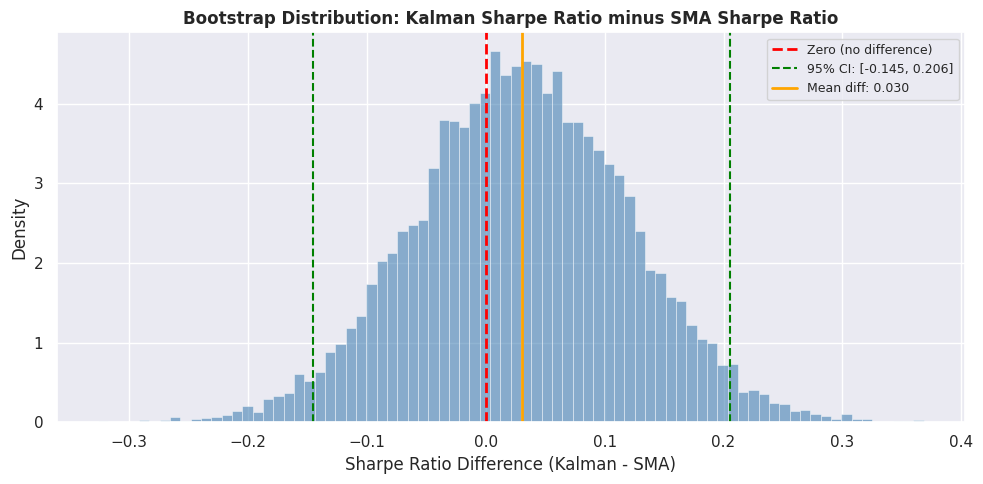

Bootstrap Analysis: Kalman vs. SMA Sharpe Ratio Difference
Number of bootstrap samples: 10,000
Mean Sharpe difference:      +0.0304
95% Confidence Interval:     [-0.1450, +0.2056]
Zero in CI?                  Yes

Conclusion: NOT significant at 95% level


In [10]:
# --- Test 2: Bootstrap confidence intervals on Sharpe ratio difference ---
# We focus on the Kalman vs. SMA comparison since that is the most
# interesting result.
#
# The bootstrap procedure:
#   1. Resample daily returns WITH replacement (same length as original)
#   2. Calculate the Sharpe ratio for both Kalman and SMA on the resample
#   3. Record the difference
#   4. Repeat 10,000 times
#   5. The 2.5th and 97.5th percentiles give the 95% confidence interval
#
# If the confidence interval excludes zero, the Sharpe difference is significant.

np.random.seed(42)  # For reproducibility
n_bootstrap = 10000

# Align Kalman and SMA returns to common dates
common_idx = portfolio_returns['Kalman'].index.intersection(
    portfolio_returns['90-day SMA (baseline)'].index)
kalman_ret = portfolio_returns['Kalman'].loc[common_idx].values
sma_ret = portfolio_returns['90-day SMA (baseline)'].loc[common_idx].values
n_days = len(kalman_ret)

# Run bootstrap
sharpe_diffs = []
for i in range(n_bootstrap):
    # Resample with replacement
    idx = np.random.choice(n_days, size=n_days, replace=True)

    # Calculate annualized Sharpe for each variant on the resample
    kalman_sample = kalman_ret[idx]
    sma_sample = sma_ret[idx]

    sharpe_kalman = (kalman_sample.mean() / kalman_sample.std()) * np.sqrt(252)
    sharpe_sma = (sma_sample.mean() / sma_sample.std()) * np.sqrt(252)

    sharpe_diffs.append(sharpe_kalman - sharpe_sma)

sharpe_diffs = np.array(sharpe_diffs)

# Calculate confidence interval
ci_lower = np.percentile(sharpe_diffs, 2.5)
ci_upper = np.percentile(sharpe_diffs, 97.5)
mean_diff = sharpe_diffs.mean()

# --- Plot the bootstrap distribution ---
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(sharpe_diffs, bins=80, density=True, alpha=0.6, color='steelblue',
        edgecolor='white', linewidth=0.5)
ax.axvline(x=0, color='red', linewidth=2, linestyle='--', label='Zero (no difference)')
ax.axvline(x=ci_lower, color='green', linewidth=1.5, linestyle='--',
           label=f'95% CI: [{ci_lower:.3f}, {ci_upper:.3f}]')
ax.axvline(x=ci_upper, color='green', linewidth=1.5, linestyle='--')
ax.axvline(x=mean_diff, color='orange', linewidth=2, label=f'Mean diff: {mean_diff:.3f}')

ax.set_title('Bootstrap Distribution: Kalman Sharpe Ratio minus SMA Sharpe Ratio',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Sharpe Ratio Difference (Kalman - SMA)')
ax.set_ylabel('Density')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Print summary
print(f"Bootstrap Analysis: Kalman vs. SMA Sharpe Ratio Difference")
print(f"=" * 55)
print(f"Number of bootstrap samples: {n_bootstrap:,}")
print(f"Mean Sharpe difference:      {mean_diff:+.4f}")
print(f"95% Confidence Interval:     [{ci_lower:+.4f}, {ci_upper:+.4f}]")
print(f"Zero in CI?                  {'Yes' if ci_lower <= 0 <= ci_upper else 'No'}")
print(f"\nConclusion: {'NOT significant at 95% level' if ci_lower <= 0 <= ci_upper else 'Significant at 95% level'}")

The bootstrap confirms what the t-test told us. The mean Sharpe ratio difference is +0.030 (Kalman is slightly better), but the 95% confidence interval spans from -0.145 to +0.206. Zero sits comfortably inside that interval, meaning we cannot rule out the possibility that the true Sharpe difference is zero — or even that the SMA is slightly better.

The histogram makes this visually clear. The distribution is centered just to the right of zero (the orange line), but it has substantial spread in both directions. In roughly 35% of bootstrap resamples, the SMA actually produced a higher Sharpe ratio than the Kalman filter. The Kalman filter's edge, while consistent in our specific sample, is not robust enough to survive the noise of resampling.

This is a textbook example of why statistical testing matters in quantitative finance. Looking at equity curves and summary tables, the Kalman filter appeared to be a clear winner: better Sharpe, lower drawdown, higher Calmar ratio. The paired t-test and bootstrap analysis reveal that these differences, while real in our sample, are well within the range of random variation. If markets had played out slightly differently — if COVID had happened six months earlier, if the 2022 drawdown had been deeper — the ranking could easily have reversed.

This does not invalidate the Kalman result. The mean difference is positive, the point estimate favors Kalman, and the structural advantages (causal, adaptive, no boundary effects) are real. It simply means that 15 years of daily data is not enough to confirm the advantage with statistical confidence. This is a common frustration in quantitative finance: strategies take decades to produce statistically significant track records, by which point the market regime may have changed entirely.

## Section 5: The Verdict

Let us consolidate everything we learned across all four notebooks in this chapter.

In [14]:
# --- Final summary table ---
verdict = {
    'Filter': [
        '90-day SMA (baseline)',
        '90-day EMA',
        'Kalman (Q=0.01, R=1.0)',
        'Fourier (>90 days)',
        'Wavelet denoise',
        'Wavelet trend'
    ],
    'Sharpe': [0.935, 0.926, 0.967, 0.573, 0.698, 0.587],
    'Max DD': ['-20.6%', '-19.6%', '-18.5%', '-25.0%', '-20.9%', '-26.2%'],
    'Boundary Safe?': ['Yes', 'Yes', 'Yes', 'No', 'No', 'No'],
    'Sig. vs SMA': ['—', 'No (p=0.96)', 'No (p=0.44)', 'Yes, worse (p=0.007)',
                     'No (p=0.24)', 'Yes, worse (p=0.03)'],
    'Verdict': [
        'Reliable baseline. Use this.',
        'Equivalent to SMA.',
        'Promising but unconfirmed. Revisit with optimization.',
        'Significantly worse. Do not use.',
        'Worse but not significantly. Not justified.',
        'Significantly worse. Do not use.'
    ]
}

df_verdict = pd.DataFrame(verdict).set_index('Filter')
print("Final Verdict: Does Filtering Improve the VIXY Strategy?")
print("=" * 130)
print(df_verdict.to_string())

Final Verdict: Does Filtering Improve the VIXY Strategy?
                        Sharpe  Max DD Boundary Safe?           Sig. vs SMA                                                Verdict
Filter                                                                                                                            
90-day SMA (baseline)   0.9350  -20.6%            Yes                     —                           Reliable baseline. Use this.
90-day EMA              0.9260  -19.6%            Yes           No (p=0.96)                                     Equivalent to SMA.
Kalman (Q=0.01, R=1.0)  0.9670  -18.5%            Yes           No (p=0.44)  Promising but unconfirmed. Revisit with optimization.
Fourier (>90 days)      0.5730  -25.0%             No  Yes, worse (p=0.007)                       Significantly worse. Do not use.
Wavelet denoise         0.6980  -20.9%             No           No (p=0.24)            Worse but not significantly. Not justified.
Wavelet trend           0.

This table is the answer to the question we posed at the beginning of this notebook.

**The simple 90-day SMA wins.** Not because it is theoretically optimal, but because it is reliable, transparent, has no boundary effects, requires no parameter optimization, and none of the advanced alternatives could significantly beat it. In quantitative finance, simple and robust beats complex and fragile almost every time.

**The 90-day EMA is a legitimate alternative** that is statistically indistinguishable from the SMA. If you prefer faster response with less lag, the EMA is a defensible choice. But the improvement is not measurable.

**The Kalman filter is the one technique worth pursuing further.** It is the only advanced filter that outperformed the baseline (higher Sharpe, lower drawdown, better Calmar), and it is the only one with zero boundary effects. The outperformance is not statistically significant in this sample, but the structural advantages are real. With proper parameter optimization, walk-forward validation (Chapter 9), and a full event-driven backtest (Chapter 8), the Kalman filter may prove to be a genuine improvement. We will revisit this in a dedicated notebook after building those tools.

**Fourier and wavelet filtering made the strategy worse.** Fourier significantly worse, wavelet trend significantly worse, wavelet denoise worse but not significantly. These techniques have genuine value in other contexts (intraday pattern detection, regime research, multi-scale analysis), but as direct replacements for the SMA in a daily-frequency tail hedge strategy, they do not help. The boundary effects problem is a major contributor: the filtered values in this backtest benefited from lookahead bias, and they still underperformed.

**The broader lesson:** Signal processing is valuable knowledge. Understanding autocorrelation, stationarity, frequency decomposition, and boundary effects makes you a better quantitative analyst. But in the specific context of building trading strategies, the bar for complexity is high. A technique must not only produce better results — it must produce significantly better results, with trustworthy boundary properties, and with parameters that are robust out-of-sample. The 90-day SMA clears that bar. Most advanced filters do not.

This conclusion is consistent with a reality that experienced practitioners know well: in quantitative finance, the biggest gains come from better strategy design, better risk management, and better data — not from fancier signal processing. The tools in this chapter are worth having in your toolkit, but they are not where alpha lives for most strategies.

**This chapter was more than an exploration of signal processing techniques.** It was your first exposure to the complete process of building, testing, and critically evaluating a trading strategy. Think about what we did across these four notebooks: we examined our data's statistical properties (6.1), applied and compared filtering techniques (6.2, 6.3), generated trading signals, ran a backtest, calculated performance metrics, and tested for statistical significance (6.4). This is the quantitative research workflow. Every step built on what we learned in earlier chapters — the data retrieval from Chapter 3, the preparation from Chapter 5, the understanding of our instruments and their behavior. And every step introduced concepts we will expand on in the chapters ahead: performance evaluation (Chapter 7), rigorous backtesting (Chapter 8), walk-forward validation (Chapter 9), and detecting flawed backtests (Chapter 10).

**This chapter also demonstrates how difficult it is to build a strategy with sustainable alpha.** We applied some of the most sophisticated tools in quantitative analysis to a well-designed strategy with a sound economic rationale, and only one technique showed any improvement — and that improvement was not statistically significant. This is not a failure. This is reality. If building profitable trading strategies were as simple as applying the right filter, everyone would be doing it. The difficulty is the point: it is what makes a genuine edge valuable.

**Finally, just because the Kalman filter did not pass our significance tests does not mean we have nothing to work with.** We have a promising lead with a clear economic rationale (less lag means fewer false signals and less contango decay drag) and a structural advantage (causal, no boundary effects). The next steps are to optimize the Q and R parameters properly, simulate different price paths using Monte Carlo methods, and test whether the Kalman variant outperforms across a majority of those simulated paths. If it does, we have something real — an improvement that is robust not just to our specific historical sample, but to a wide range of plausible market outcomes. We will build the tools to do exactly this in the chapters ahead.